<a href="https://colab.research.google.com/github/simulate111/TOPSIS_Thes/blob/main/TOPSIS%2BTEA%2BLCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This will open an upload dialog below the cell
uploaded = files.upload()

Saving LCA.csv to LCA.csv


In [3]:
import pandas as pd
import numpy as np

# ===============================
# STEP 1 & 2: LOAD CSV & EXTRACT CLEAN ROWS
# ===============================
# Read "LCA.csv" verbatim. We use latin1 encoding to handle special characters in city names.
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

# Map the exact CSV column headers to the clean names required for TOPSIS
column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    '\\f:Times New Roman(CO)\\-(\\f:Times New Roman(2))\\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

# Apply the mapping, rename columns, and drop the first two rows (metadata/units)
df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()

# Drop rows without a valid City name
df = df.dropna(subset=['City'])

# Convert all cost and emission columns to numeric floats, dropping any invalid rows
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

print("Cleaned data preview:")
print(df.head())


# ===============================
# STEP 3: TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)

    norm = np.sqrt((X**2).sum(axis=0))
    Y = X / norm
    Yw = Y * weights

    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))

    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))

    return Snegative / (Splus + Snegative)


# ===============================
# STEP 4: RUN TOPSIS FOR ALL CITIES
# ===============================
weights = [0.5, 0.5]
criteria = [0, 0]  # both cost

results = []

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]

    scores = topsis(X, weights, criteria)
    best_idx = np.argmax(scores)

    scenario_names = ["Wind", "NoWind", "PV"]

    results.append({
        "City": row["City"],
        "Best": scenario_names[best_idx],
        "Scores": scores
    })


# ===============================
# STEP 5: OUTPUT
# ===============================
results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df.head(10))


# ===============================
# STEP 6: DOWNLOAD RESULTS
# ===============================
results_df.to_excel("topsis_results.xlsx", index=False)

from google.colab import files
files.download("topsis_results.xlsx")

Cleaned data preview:
        City  LCOE_Wind    CO2_Wind  LCOE_NoWind  CO2_NoWind   LCOE_PV  \
0      Turku   0.346154   95.842278     0.533846  171.664504  1.692308   
1   Helsinki   0.260000   69.848794     0.555385  203.718880  1.707692   
2       Oulu   0.221538   57.269850     0.567692  179.795599  2.938462   
3    Tampere   0.369231  103.234448     0.606154  211.767307  2.723077   
4  Mariehamn   0.264615   83.272083     0.535385  181.847994  1.676923   

        CO2_PV  
0  1435.480769  
1  1181.154785  
2  1869.813341  
3  2016.721215  
4  1317.929515  

Final Results:
         City  Best                          Scores
0       Turku  Wind  [1.0, 0.9030033194916672, 0.0]
1    Helsinki  Wind  [1.0, 0.8395564917345069, 0.0]
2        Oulu  Wind  [1.0, 0.9003397302561926, 0.0]
3     Tampere  Wind  [1.0, 0.9211176690689659, 0.0]
4   Mariehamn  Wind   [1.0, 0.863129356466213, 0.0]
5     Aalborg  Wind  [1.0, 0.7695389482679655, 0.0]
6      Aarhus  Wind  [1.0, 0.7020772099698775, 0.0]

<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2069/3336139846.py:14: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh': 'CO2_Wind',
/tmp/ipykernel_2069/3336139846.py:16: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh.1': 'CO2_NoWind',


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. LOAD DATA
# ===============================
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    '\\f:Times New Roman(CO)\\-(\\f:Times New Roman(2))\\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ===============================
# 2. TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)

    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights

    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))

    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))

    denom = Splus + Snegative
    denom[denom == 0] = 1e-10

    return Snegative / denom

# ===============================
# 3. SENSITIVITY ANALYSIS LOOP
# ===============================
results = []
w_lcoe_range = np.linspace(0, 1, 101) # 0 to 1.00 in 0.01 steps

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    city = row["City"]

    for w_l in w_lcoe_range:
        w_c = 1.0 - w_l
        scores = topsis(X, [w_l, w_c], [0, 0])
        best_idx = np.argmax(scores)
        scenario_names = ["Wind", "No Wind", "PV"]

        # Adding the explicit values here
        results.append({
            "City": city,
            "LCOE_Weight_%": round(w_l * 100, 2),
            "CO2_Weight_%": round(w_c * 100, 2),
            "Best_Scenario": scenario_names[best_idx],
            "Score_Wind": scores[0],
            "Score_NoWind": scores[1],
            "Score_PV": scores[2]
        })

res_df = pd.DataFrame(results)

# ===============================
# 4. VIEW & DOWNLOAD RESULTS
# ===============================
# Print a preview of the first 10 rows to the console
print("\nSensitivity Analysis Results Preview:")
print(res_df.head(10))

# Export the FULL dataset with values to Excel
excel_filename = "sensitivity_analysis_values.xlsx"
res_df.to_excel(excel_filename, index=False)
print(f"\nResults successfully exported to {excel_filename}")

# Download the file if running in Google Colab
try:
    from google.colab import files
    files.download(excel_filename)
except ImportError:
    pass # Ignore if not running in Colab

<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2069/2435570917.py:14: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh': 'CO2_Wind',
/tmp/ipykernel_2069/2435570917.py:16: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh.1': 'CO2_NoWind',



Sensitivity Analysis Results Preview:
    City  LCOE_Weight_%  CO2_Weight_% Best_Scenario  Score_Wind  Score_NoWind  \
0  Turku            0.0         100.0          Wind         1.0      0.943401   
1  Turku            1.0          99.0          Wind         1.0      0.943392   
2  Turku            2.0          98.0          Wind         1.0      0.943363   
3  Turku            3.0          97.0          Wind         1.0      0.943314   
4  Turku            4.0          96.0          Wind         1.0      0.943244   
5  Turku            5.0          95.0          Wind         1.0      0.943151   
6  Turku            6.0          94.0          Wind         1.0      0.943034   
7  Turku            7.0          93.0          Wind         1.0      0.942892   
8  Turku            8.0          92.0          Wind         1.0      0.942723   
9  Turku            9.0          91.0          Wind         1.0      0.942527   

   Score_PV  
0       0.0  
1       0.0  
2       0.0  
3       0.0  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

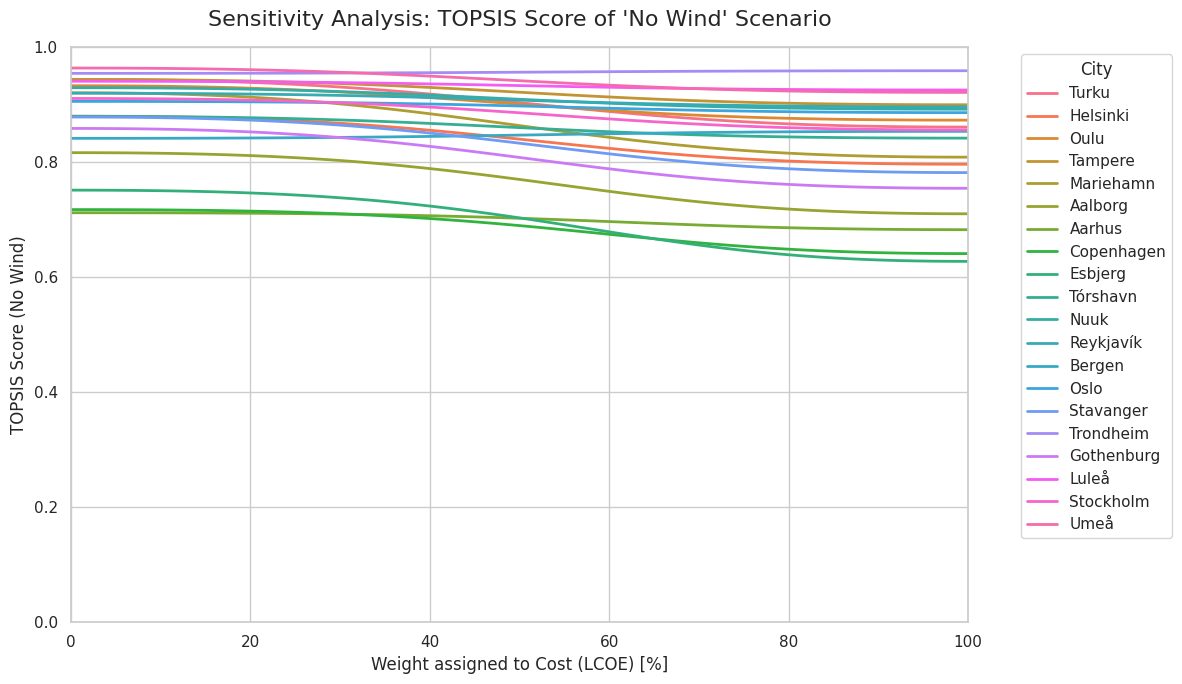

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. LOAD DATA
# ===============================
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

# Added 'r' before strings with backslashes to fix the SyntaxWarning
column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    r'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    r'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    r'\f:Times New Roman(CO)\-(\f:Times New Roman(2))\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ===============================
# 2. TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)
    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights
    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))
    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))
    denom = Splus + Snegative
    denom[denom == 0] = 1e-10
    return Snegative / denom

# ===============================
# 3. CALCULATE RESULTS
# ===============================
results = []
w_lcoe_range = np.linspace(0, 1, 101)

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    city = row["City"]
    for w_l in w_lcoe_range:
        w_c = 1.0 - w_l
        scores = topsis(X, [w_l, w_c], [0, 0])
        results.append({
            "City": city,
            "LCOE_Weight_%": w_l * 100,
            "Score_NoWind": scores[1] # Index 1 is No Wind
        })

res_df = pd.DataFrame(results)

# ===============================
# 4. PLOT RESULTS
# ===============================
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.lineplot(data=res_df, x='LCOE_Weight_%', y='Score_NoWind', hue='City', linewidth=2)

plt.title("Sensitivity Analysis: TOPSIS Score of 'No Wind' Scenario", fontsize=16, pad=15)
plt.xlabel("Weight assigned to Cost (LCOE) [%]", fontsize=12)
plt.ylabel("TOPSIS Score (No Wind)", fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 1)

# Fixed the legend line so it doesn't contain the accidental text
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()